# Document Intelligence Playground
This notebook demonstrates the end-to-end pipeline:
1. **Parsing**: Vision-Language Model (PaddleOCR-VL) extraction from PDFs/Images.
2. **Ingestion**: Secure Merkle-tree versioning and Qdrant Vector stored ingestion.
3. **Retrieval**: Hybrid Reranking (Recall-to-Precision) for high-accuracy response generation.

In [5]:
import os
import sys
import asyncio
import logging
from pathlib import Path
from typing import List
from dotenv import load_dotenv

# Ensure 'src' is in path
if "./src" not in sys.path:
    sys.path.insert(0, "./src")

# Silencing noisy HTTP and system logs
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

# Load environment variables from .env
load_dotenv()

from document_parser import DocumentParser
from ingestion_pipeline import AsyncMerkleQdrantIngestor
from reranker_pipeline import HybridReranker, format_citation
from shared.schemas import Document, PipelineSettings
from utils import display_layout_interactive, display_layout_interactive_batch

print(f"✅ Pipeline components imported successfully.")
print(f"📍 Using VLM_SERVER_URL: {os.getenv('VLM_SERVER_URL', 'Not Set')}")


✅ Pipeline components imported successfully.
📍 Using VLM_SERVER_URL: http://localhost:8111/v1


## Stage 1: Document Parsing
Extract structured `Document` objects with Markdown text and spatial grounding.

In [2]:
# Configure for MLX high-precision/high-recall
settings = PipelineSettings(
    vl_rec_backend="mlx-vlm-server",
    use_doc_preprocessor="false",
    use_layout_detection="true",
    use_chart_recognition="false",
    use_seal_recognition="false",
    use_ocr_for_image_block="false",
    format_block_content="false",
    merge_layout_blocks="true"
)

parser = DocumentParser(settings=settings)

# Path to your document
file_path = "./data/bbs.pdf"

print(f"Parsing: {file_path}...")
documents: List[Document] = parser.parse(file_path)

print(f"✅ Parsed {len(documents)} pages.")
if documents:
    print(f"--- Page 1 Markdown Snippet ---\n{documents[0].markdown[:500]}...")

Parsing: ./data/bbs.pdf...


Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.
/Users/en_tetteh/Downloads/dataextraction/.venv/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/en_tetteh/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('PP-DocLayoutV3', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/en_tetteh/.paddlex/official_models/PP-DocLayoutV3`.
Creating model: ('PaddleOCR-VL-1.5-0.9B', None)
/Users/en_tetteh/Downloads/dataextraction/.venv/lib/python3.

✅ Parsed 4 pages.
--- Page 1 Markdown Snippet ---
# Multi-Domain Balanced Sampling Improves Out-of-Distribution Generalization of Chest X-ray Pathology Prediction Models

Enoch Tetteh Mila, Quebec AI Institute AMMI, AIMS Rwanda etetteh@aimsammi.org

Joseph Viviano Mila, Quebec AI Institute University of Montreal

Yoshua Bengio Mila, Quebec AI Institute University of Montreal





David Krueger

Mila, Quebec AI Institute

University of Montreal

University of Cambridge

Joseph Paul Cohen

Mila, Quebec AI Institute

AIMI, Stanford University

## ...



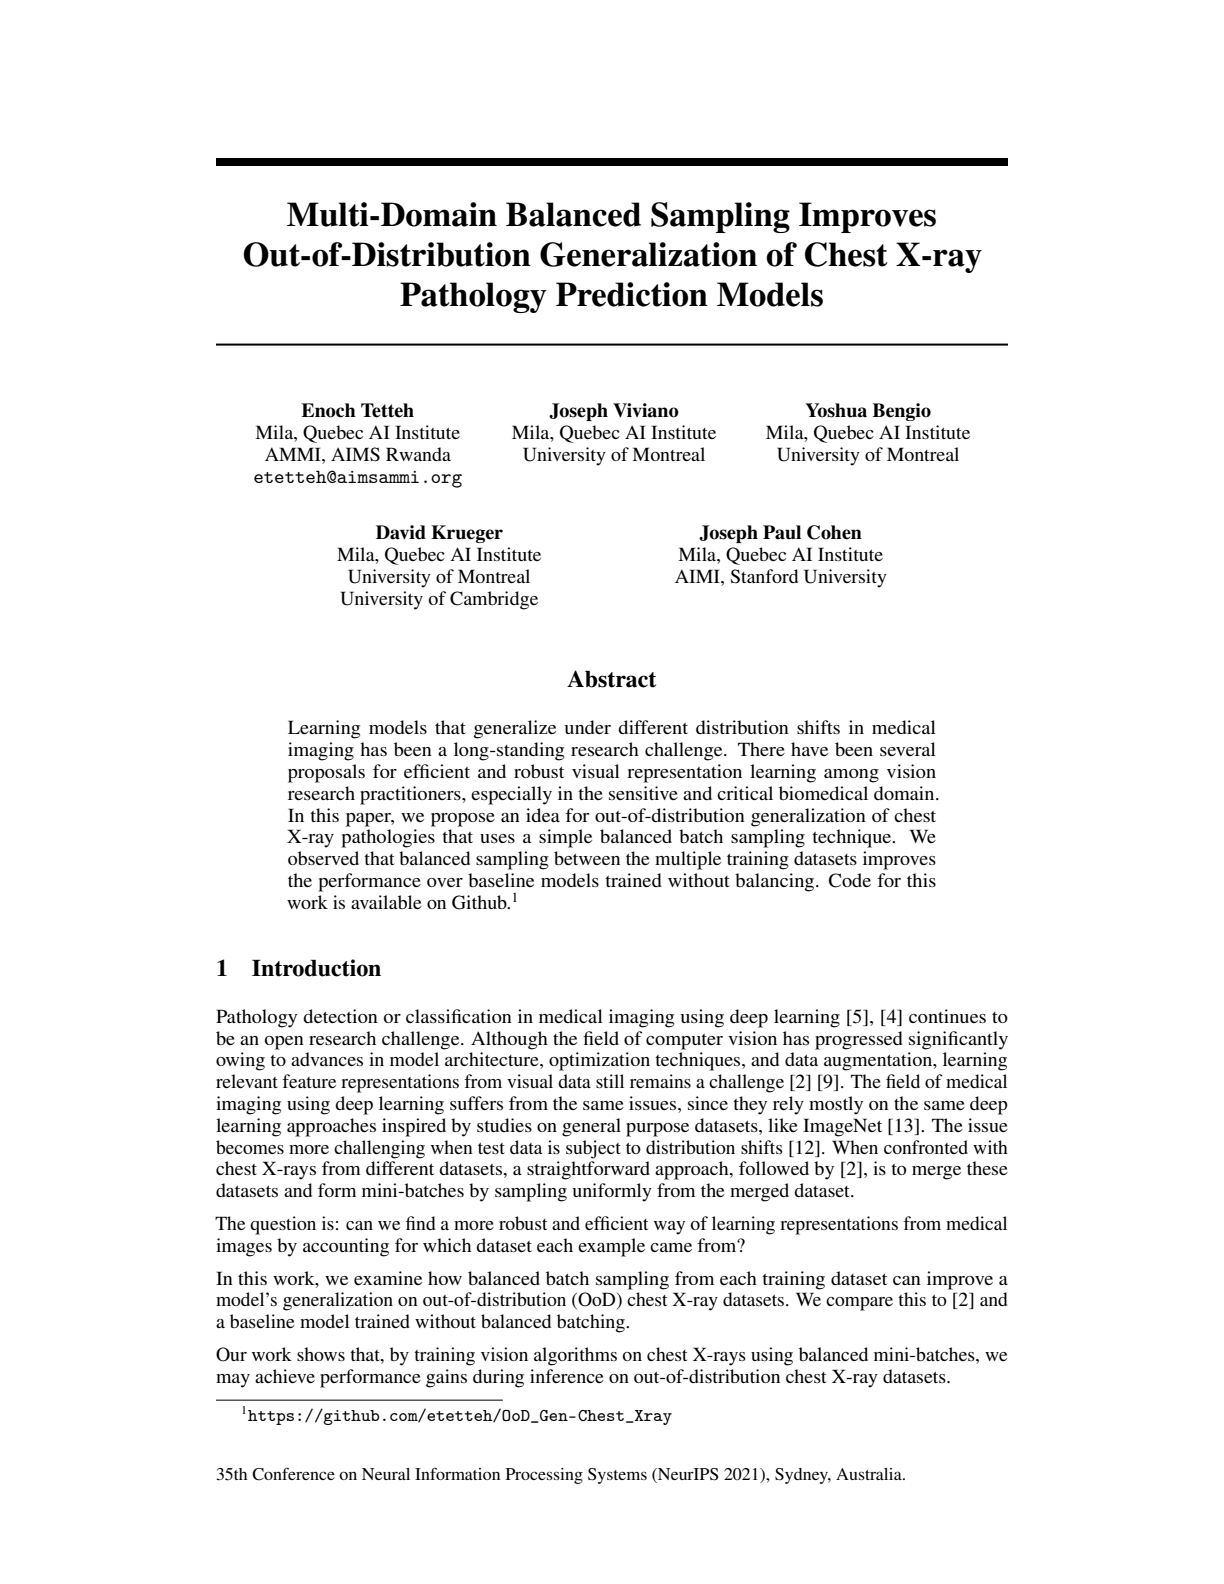
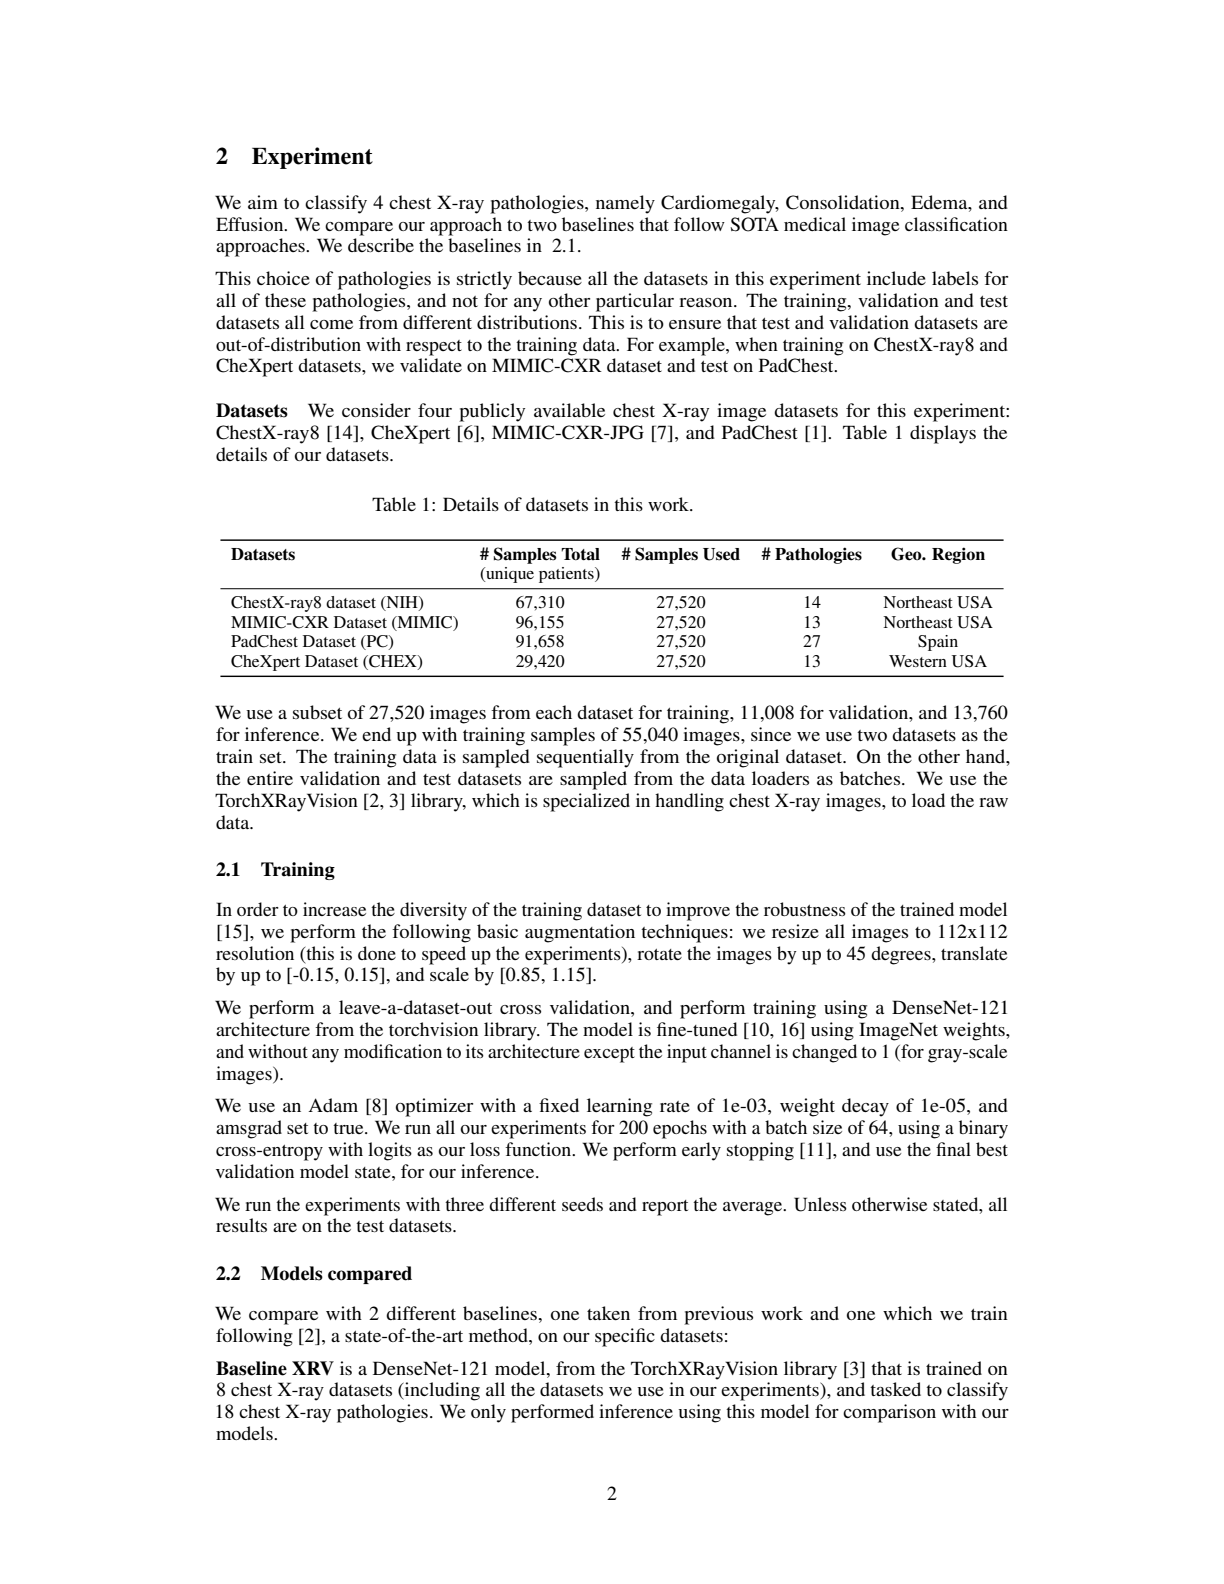
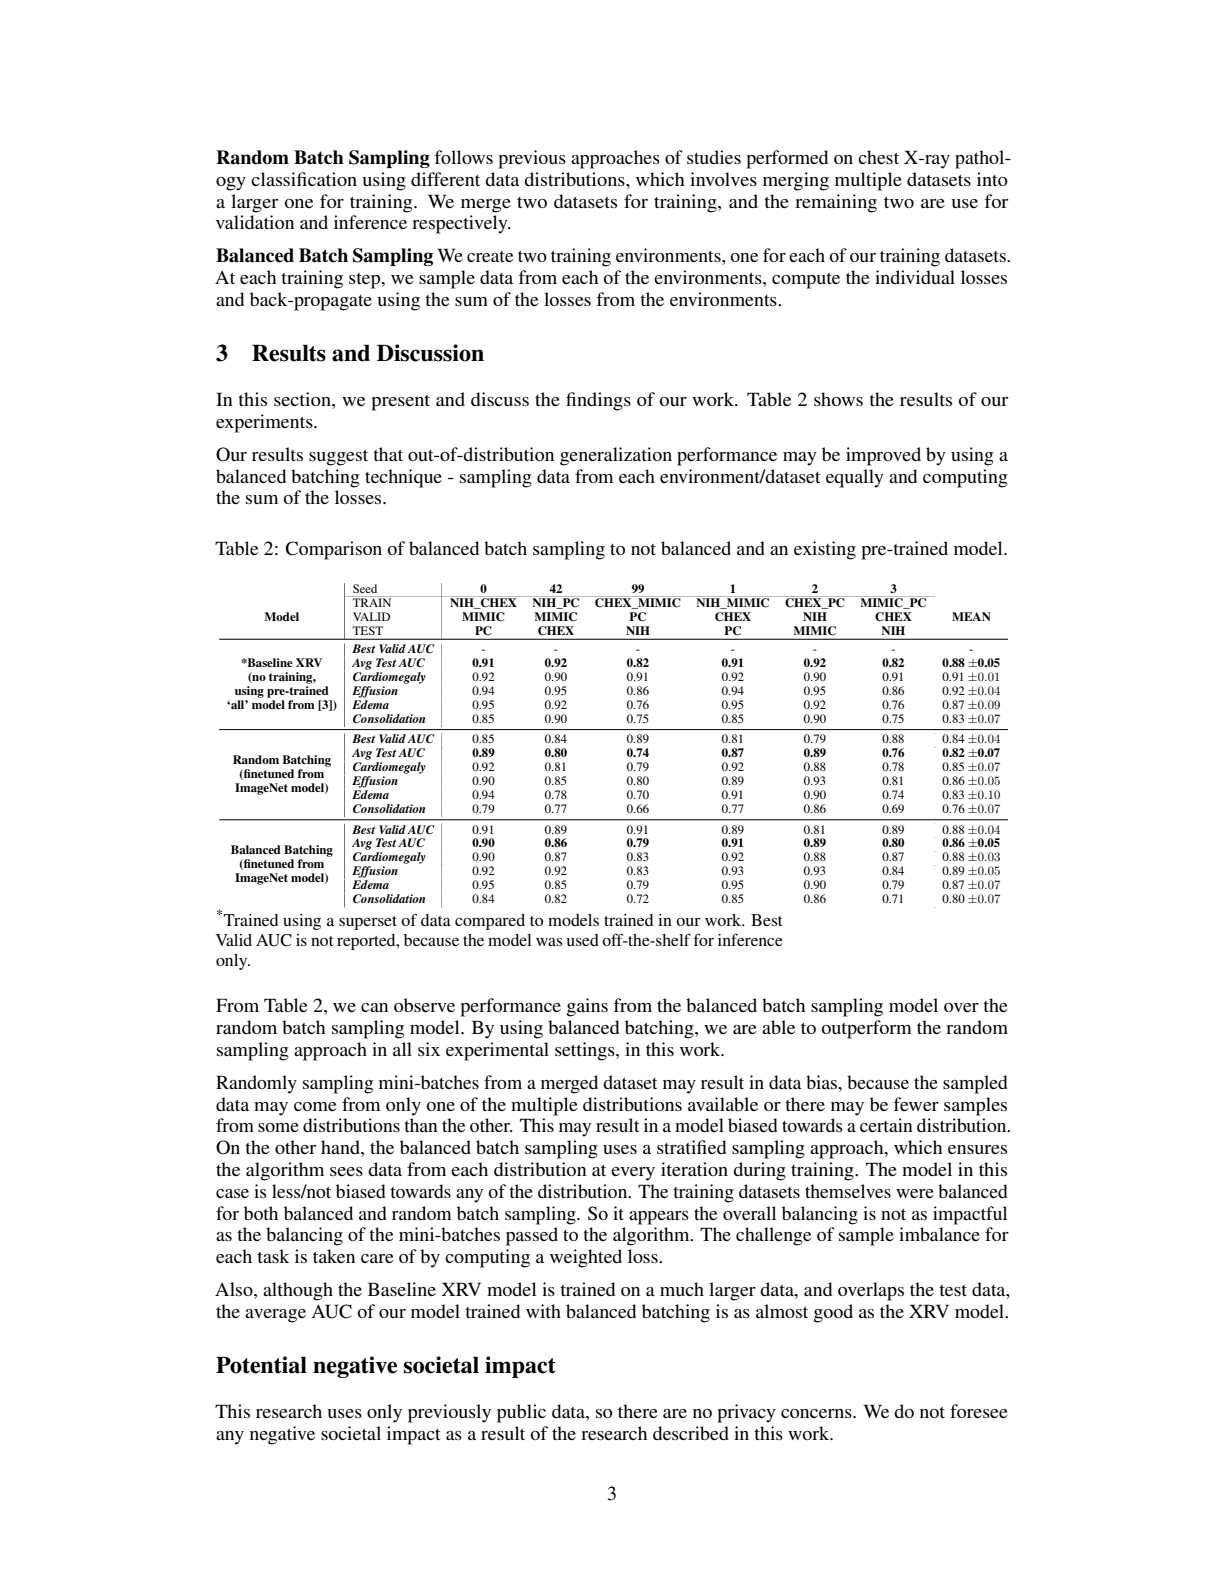
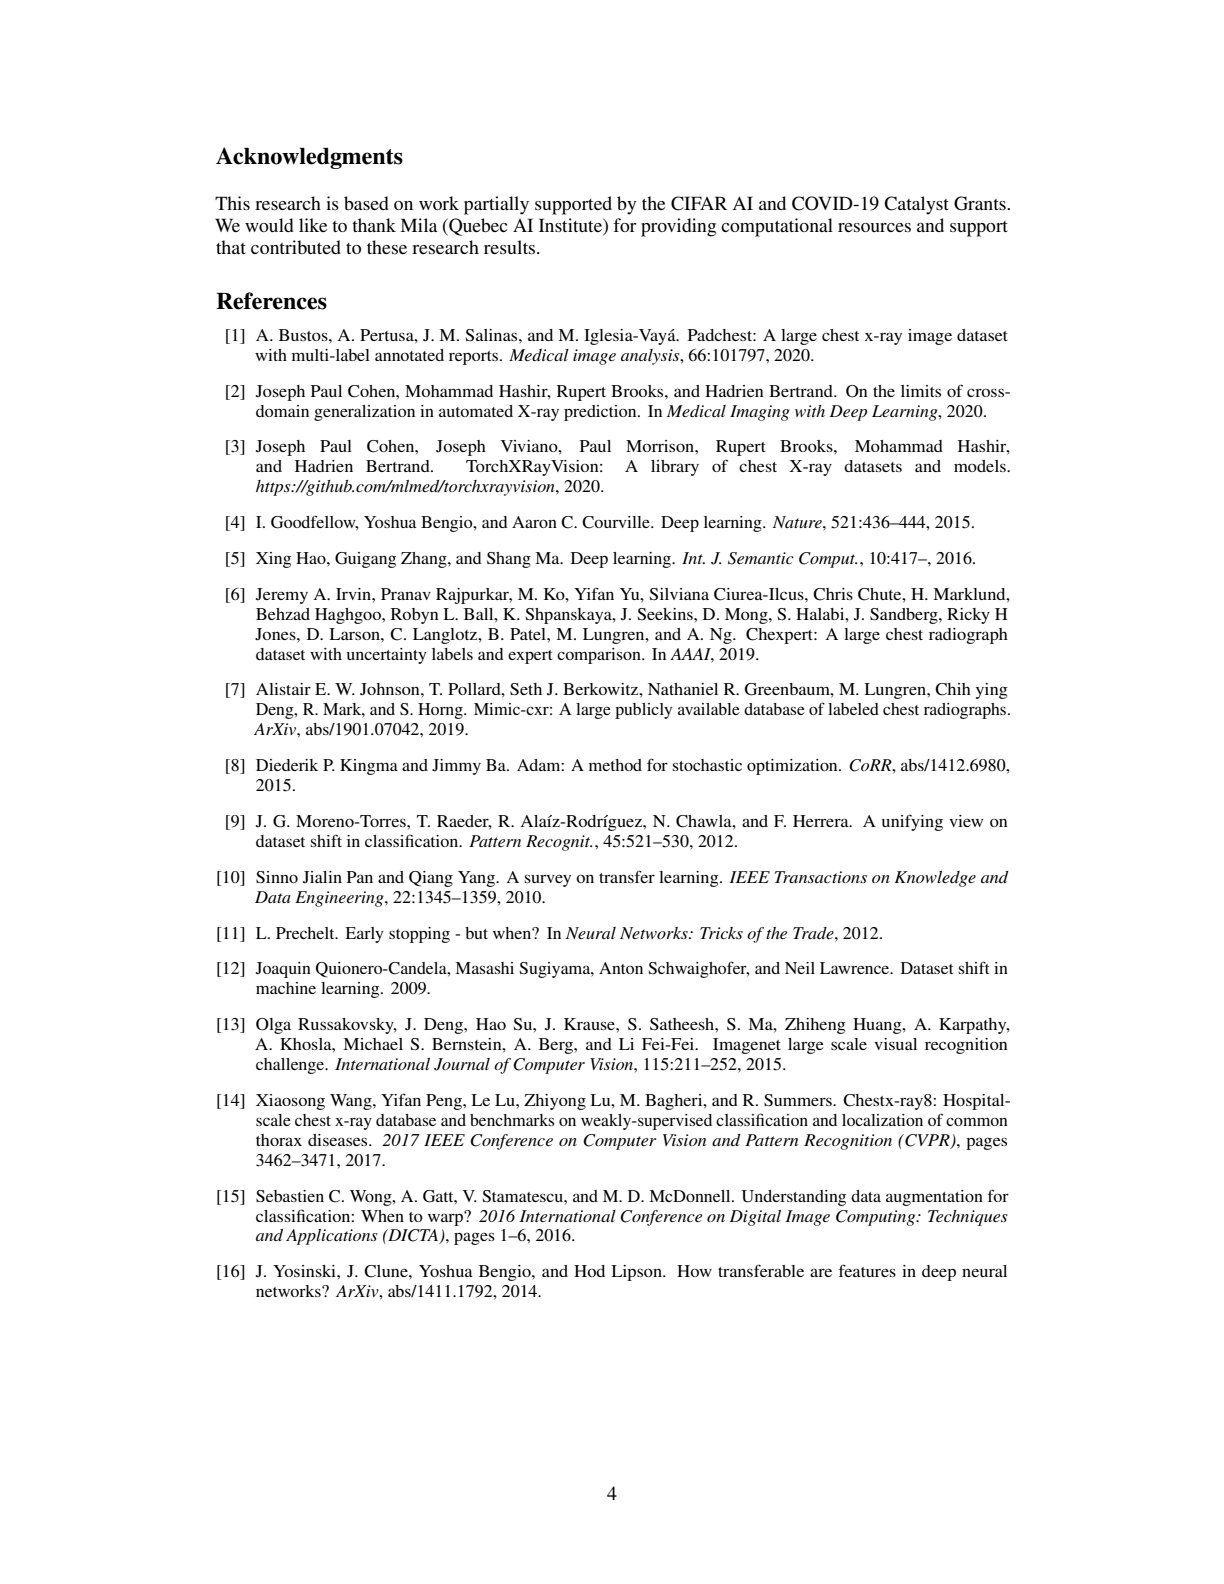

In [6]:
if documents:
    # Display the first page interactively
    display_layout_interactive_batch(documents)

## Stage 2: Secure Ingestion
Store the parsed documents in Qdrant with Merkle-tree fingerprinting for provenance.

In [7]:
# Initialize Ingestor
ingestor = AsyncMerkleQdrantIngestor(
    qdrant_url="http://localhost:6333",
    collection_base_name="document_intelligence"
)

# Setup collection and indexes
await ingestor.setup()

# Ingest all pages
for doc in documents:
    await ingestor.process_document(doc)

print(f"✅ {len(documents)} pages ingested into Qdrant.")

# Verify Merkle Integrity
if documents:
    is_valid = await ingestor.verify_integrity(
        filename=documents[0].metadata.filename,
        page_index=documents[0].metadata.page_index
    )
    print(f"🔐 Merkle Integrity Check: {'Passed' if is_valid else 'FAILED'}")

2026-04-10 07:00:10,934 - INFO - Use pytorch device_name: mps
2026-04-10 07:00:10,935 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-10 07:00:13,622 - INFO - Loaded SentenceTransformers for BAAI/bge-small-en-v1.5


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-10 07:00:14,362 - INFO - Payload indexes ensured for collection: document_intelligence_baai-bge-small-en-v1.5
2026-04-10 07:00:14,375 - INFO - New snapshot for bbs.pdf p.1 — root: cdba59a1...


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-10 07:00:17,114 - INFO - Snapshot 3a846cf2... committed successfully.
2026-04-10 07:00:17,120 - INFO - New snapshot for bbs.pdf p.4 — root: 2f6619a2...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-10 07:00:17,532 - INFO - Snapshot 2f6619a2... committed successfully.
2026-04-10 07:00:17,539 - INFO - Integrity verified for bbs.pdf p.1 (15 chunks)


✅ 4 pages ingested into Qdrant.
🔐 Merkle Integrity Check: Passed


## Stage 3: Hybrid Reranking
Query the vector store with RRF Recall and Cross-Encoder Precision.

In [8]:
# Initialize Reranker
reranker = HybridReranker(ingestor=ingestor, alpha=0.7)

# Run Query
query = "What was the percentage gain when using balanced batch sampling?"
print(f"Querying: {query}\n" + "="*40)

results = await reranker.rerank(
    query=query,
    retrieval_top_k=20,
    rerank_top_n=7
)

# Display Precision Results with Citations
if results:
    for i, res in enumerate(results, start=1):
        print(format_citation(res, index=i))
        print(f"Content: {res.content}\n")
else:
    print("No results found. Ensure the document mentions sales data!")

2026-04-10 07:00:52,346 - INFO - Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-10 07:00:53,322 - INFO - Use pytorch device: mps
2026-04-10 07:00:53,679 - INFO - HybridReranker ready (alpha=0.70, RRF k=60)


Querying: What was the percentage gain when using balanced batch sampling?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-10 07:00:53,963 - INFO - rerank() → 7 results from 20 fused candidates (query: 'What was the percentage gain when using balanced batch sampl'...)


[1] bbs.pdf · p.3 · chunk 9 · score 1.000
      CE=3.720 RRF=0.0328 sources=['vector', 'sparse']
      Merkle: 3a846cf2e9ea... hash: 43ba4865ce87... (2026-04-10T11:00:17.091049+00:00)
      bbox: [209, 994, 1011, 1064]
Content: From Table 2, we can observe performance gains from the balanced batch sampling model over the random batch sampling model. By using balanced batching, we are able to outperform the random sampling approach in all six experimental settings, in this work.

[2] bbs.pdf · p.3 · chunk 4 · score 0.858
      CE=1.081 RRF=0.0315 sources=['vector', 'sparse']
      Merkle: 3a846cf2e9ea... hash: 3d4b3b11a489... (2026-04-10T11:00:17.091049+00:00)
      bbox: [210, 444, 1012, 511]
Content: Our results suggest that out-of-distribution generalization performance may be improved by using a balanced batching technique - sampling data from each environment/dataset equally and computing the sum of the losses.

[3] bbs.pdf · p.3 · chunk 10 · score 0.858
      CE=1.080 RRF=0.0315 s

In [ ]:
{"file_path": "/Users/en_tetteh/Downloads/dataextraction/data/virology_pg2.pdf",
"vl_rec_backend": "mlx-vlm-server",
"use_doc_preprocessor": "false",
"use_layout_detection": "true",
"use_chart_recognition": "false",
"use_seal_recognition": "false",
"use_ocr_for_image_block": "false",
"format_block_content": "false",
"merge_layout_blocks": "true"
}

In [ ]:
{
  "file_path": "/Users/en_tetteh/Downloads/dataextraction/virology_pg2/documents.json"
}




In [ ]:
import json 


In [ ]:
with open("src/Essential-GraphRAG-sample/documents.json", "r") as file:
    docs = [Document(**data) for data in json.load(file)]

In [ ]:
docs

In [ ]:
display_layout_interactive(docs[1])